cos:  1.0
Laenge: 912 
Breite: 624 
Dicke: 3.6
Auflager: Min
q = 0.024525
D = 6159152.500615914
maxh: 30
min w [mm]        = -3.0890140917673854
max w [mm]        = 0.03829188531611149
max z-Abstand [mm]= 3.127305977083497
max |w| [mm]      = 3.0890140917673854
Scale in Visualization:  100


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Vectors': False…

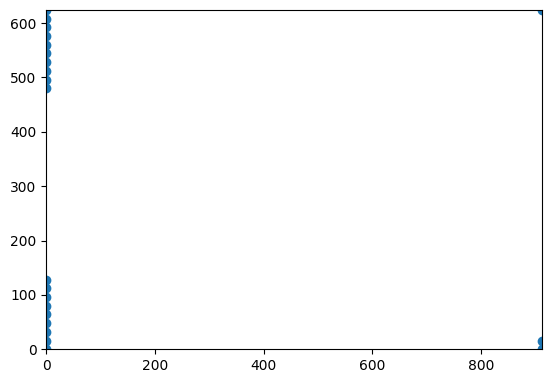

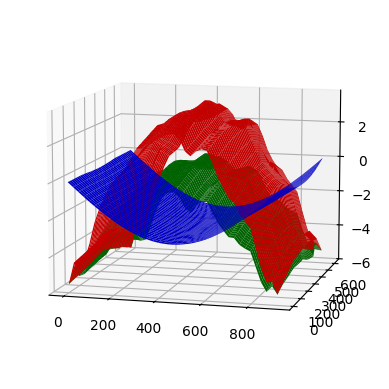

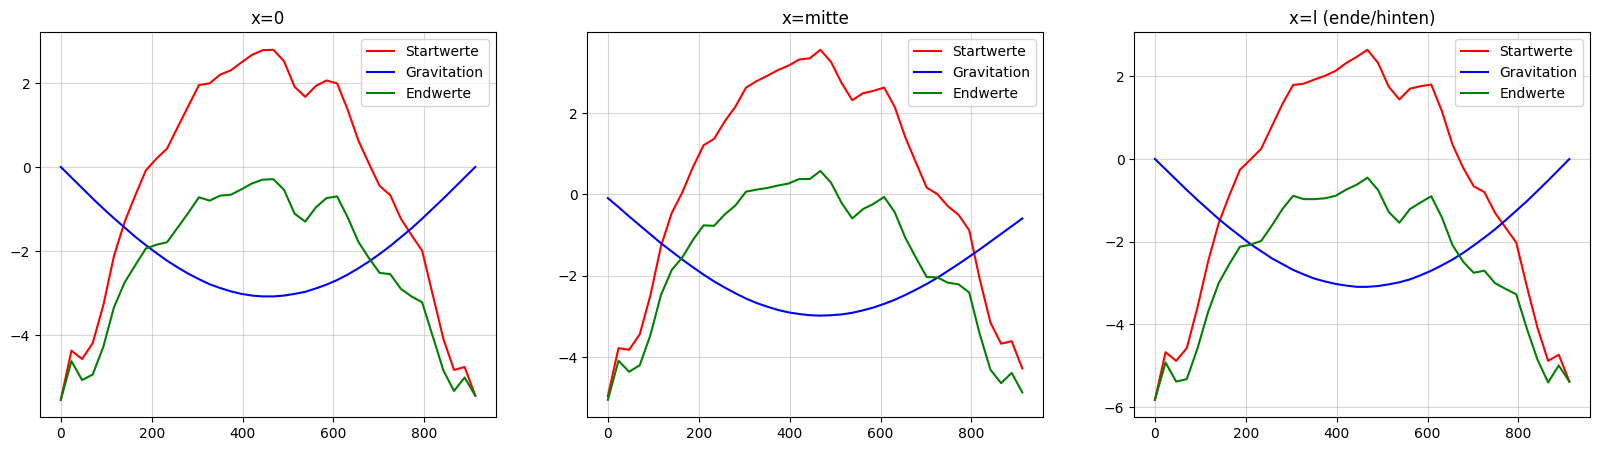

In [ ]:
import numpy as np
from math import sqrt, pi, cos
# import pyvista as pv
# pv.set_jupyter_backend('trame')

#RM_nVexAKTUELL.ipynb
from ngsolve import *
from netgen.geom2d import SplineGeometry
from ngsolve.webgui import Draw
import matplotlib.pyplot as plt
from ngsolve import x,y
from netgen.occ import *
from math import pi, cos, sqrt
from ngsolve.fem import NODE_TYPE
from ngsolve.meshes import MakeStructured2DMesh

# xyzFile_zusammenrechnen_EW.py
import matplotlib.pyplot as plt

# HC_AuflagerMinima.py
np.set_printoptions(threshold=np.inf)

"""
21.5
Hauptcode, allerdings ohne HeaderFiles, alle zusätzlichen Funktionen aus anderen Files, hab ich hineinkopiert, damit das File hoffentlich auch im Browser läuft

Reissner Mindlin ohne TDNNS
nearest Vertex -> simply supported bei analysierten Punktauflager

1. nimmt Messwerte.xyz file
2. analysiert Auflagerpunkte + tol
3. berechnet gravitation mit RM_nVex_AKTUELL
    - aktuelle Variationsformulierung (wie in ngSolve)
    - Reissner Mindlin ohne TDNNS
    - nearest Vertex -> freeDofs = 0
4. zusammenrechnen und simulieren
"""

#RM_nVexAKTUELL.ipynb
def ReissnerMindlin_GRAV_Punkte(Lx,Ly,t,AuflagerListe,scale=1,step=40,maxh=8,Neigungsfaktor_cos=1):
    #region PARAMETER (MILLIMETER)
    E  = 70e6
    nu = 0.23
    rho = 2.5e-6
    g = 9810

    q = rho * g * Neigungsfaktor_cos
    D = E/(12*(1-nu**2))      # Biegesteifigkeit
    G = E/(2*(1+nu))
    ks = 5/6                       # Schubkorrektur
    S = ks*G/t**2                     # Schubsteifigkeit
    # A = E*t/(1-nu**2)              # Membransteifigkeit
    print("q =", q)
    print("D =", D)
    #endregion

    #region GEOMETRIE
    shape = MoveTo(0,0).Rectangle(Lx,Ly).Face()
    shape.edges.name="free"
    rect = shape 
    geo = OCCGeometry(rect,dim=2)
    mesh = Mesh(geo.GenerateMesh(maxh=maxh))

    mesh.Curve(3)
    #endregion

    #region FEM-Räume
    order = 2
    Vw = H1(mesh, order=order)      # Durchbiegung
    Vb = VectorH1(mesh, order=order)    # Rotation
    X = FESpace([Vw, Vb])

    u, beta = X.TrialFunction()
    v, eta  = X.TestFunction()

    gf = GridFunction(X)
    w, rot = gf.components
    #endregion
    
    #region FEM
    a = BilinearForm(X, symmetric=True)
    # Biegung
    a += D * ((1-nu)*InnerProduct(Sym(Grad((beta))), Sym(Grad((eta)))) + nu*Trace(Sym(Grad((beta))))*Trace(Sym(Grad((eta))))) * dx
    # Schub: grad(w)-beta
    a += S * InnerProduct(Grad(u)-beta, Grad(v)-eta) * dx

    f = LinearForm(X)
    f += -q * v/(t**2) * dx

    a.Assemble()
    f.Assemble()

    import numpy as np
    # Nearest_Vertex_ID Liste basteln
    meshPunkte = mesh.vertices      # holen uns die Menge aller Punkte aus unserem Mesh
    anzahl_auflager = len(AuflagerListe)
    Nearest_Vertex_ID = np.zeros(anzahl_auflager)       # speichert jeweils für alle AuflagerPunkte den nächsten meshPunkt
    for i,punkt in enumerate(AuflagerListe):
        distances = [np.linalg.norm( np.array(mPunkt.point) - punkt ) for mPunkt in meshPunkte]
        # print([mPunkt.point for mPunkt in meshPunkte])
        vertexNr = np.argmin(distances)
        Nearest_Vertex_ID[i] = vertexNr

    free_dofs = X.FreeDofs()        # holt alle Freiheitsgrade

    for vertexNummer in Nearest_Vertex_ID.astype(int):
        for dof in Vw.GetDofNrs(NodeId(NODE_TYPE.VERTEX, vertexNummer)):
            free_dofs[dof] = False

    gf.vec[:] = 0
    # gfu.vec.data = a.mat.Inverse(free_dofs) * f.vec
    gf.vec[:] = a.mat.Inverse(freedofs=free_dofs) * f.vec
    # Draw(w, mesh,euler_angles=[-60,-10,-20], deformation=True, scale=scale);

    print("maxh:",maxh)
    # print("min w [mm] =", min(w.vec.FV().NumPy()))

    w_values = w.vec.FV().NumPy()

    w_min = np.min(w_values)
    w_max = np.max(w_values)
    w_diff = w_max - w_min
    w_abs_max = np.max(np.abs(w_values))

    print("min w [mm]        =", w_min)
    print("max w [mm]        =", w_max)
    print("max z-Abstand [mm]=", w_diff)
    print("max |w| [mm]      =", w_abs_max)

    print("Scale in Visualization: ",scale)

    Draw(w, mesh,deformation=True,euler_angles=[-60,5,30],settings={'Objects': {'Vectors': False, 'Wireframe': False, 'Surface': True}},scale=scale)

    # Draw(w,mesh,deformation=True,euler_angles=[-60,5,30],scale=scale)
    #endregion

    #region PLOTTEN
    import numpy as np
    #erzeugt gitter für gewünschte werte
    # x_points = np.round(np.linspace(0,l, step)).astype(int)
    # y_points = np.round(np.linspace(0,b, step)).astype(int)
    x_points_ungerundet = np.linspace(0,Lx, step)
    x_points = np.round(x_points_ungerundet, 2)
    y_points_ungerundet = np.linspace(0,Ly, step)
    y_points = np.round(y_points_ungerundet, 2)

    X_mesh, Y_mesh = np.meshgrid(x_points, y_points)
    #speichert (x,y,z) in gravitation_matrix für alle (x,y) in X_mesh,Y_mesh
    gravitation_matrix = np.zeros((step, step),dtype=object)
    for i in range(step):
        for j in range(step):
            try:
                z_eintrag = w(X_mesh[i, j], Y_mesh[i, j])
            except:
                z_eintrag = 0
            gravitation_matrix[i, j] = (float(X_mesh[i,j]), float(Y_mesh[i,j]), z_eintrag)

    #*.xyz file erstellen
    filename_GRAV = f"xyzFiles/{t}mm_gravitation.xyz"
    with open(filename_GRAV, "w") as f:
        for i in range(step):
            for j in range(step):
                x, y, z_w = gravitation_matrix[i, j]
                f.write(f"{x:.2f}\t{y:.2f}\t{z_w:.2f}\n")

    import matplotlib.pyplot as plt

    xs = [x[0] for x in AuflagerListe]
    ys = [x[1] for x in AuflagerListe]
    plt.scatter(xs, ys)
    plt.xlim(0, Lx)
    plt.ylim(0, Ly)

    plt.gca().set_aspect('equal', adjustable='box')  # optional: gleiche Skalierung
    plt.show()
    #endregion

    return filename_GRAV

# xyzFile_zusammenrechnen_EW.py
def plotten(l,b,t,step,filename_MW,filename_GRAV,Vorzeichen):

    data_MW = np.loadtxt(filename_MW)
    data_GRAV = np.loadtxt(filename_GRAV)

    if Vorzeichen == "Max":
    #startwerte/messwerte
        # array100 = np.full(1600,100)
        # x_MW = data_MW[:,0]
        # y_MW = data_MW[:,1]
        z_MW = -(data_MW[:,2])
    if Vorzeichen == "Min":
        #startwerte/messwerte
        # x_MW = data_MW[:,0]
        # y_MW = data_MW[:,1]
        z_MW = (data_MW[:,2])

    #gravitationswerte
    x_GRAV = data_GRAV[:,0]
    y_GRAV = data_GRAV[:,1]
    z_GRAV = data_GRAV[:,2]
    #endwerte
    x_EW = x_GRAV
    y_EW = y_GRAV
    z_EW = z_MW + z_GRAV

    np.set_printoptions(threshold=np.inf)

    filename_EW = f"xyzFiles/{t}mm_endwerte.xyz"
    with open(filename_EW, "w") as f:
        for i in range(len(x_EW)):
            x, y, w = x_EW[i],y_EW[i],z_EW[i]
            f.write(f"{x:.6f}\t{y:.6f}\t{w:.6e}\n")

    # Raster erzeugen
    #%matplotlib ipympl
    X_unique = np.unique(x_GRAV)
    Y_unique = np.unique(y_GRAV)

    X, Y = np.meshgrid(X_unique, Y_unique)

    Z_MW = z_MW.reshape(len(Y), len(X))
    Z_GRAV = z_GRAV.reshape(len(Y), len(X))
    Z_EW = z_EW.reshape(len(Y), len(X))
    
    # 3D PLOT ---- PyVista
    # grid_MW = pv.StructuredGrid(X, Y, Z_MW)
    # grid_GRAV = pv.StructuredGrid(X, Y, Z_GRAV)
    # grid_EW = pv.StructuredGrid(X, Y, Z_EW)

    # plotter = pv.Plotter()
    # plotter.set_scale(1, 1, 7)  # Y-Achse gestaucht

    # plotter.add_mesh(grid_MW, color="red", opacity=0.9, label="Startwerte")
    # plotter.add_mesh(grid_GRAV, color="blue", opacity=0.9, label="Gravitation")
    # plotter.add_mesh(grid_EW, color="green", opacity=0.9, label="Endwerte")

    # plotter.add_axes()
    # plotter.add_legend()

    # plotter.show(jupyter_backend=None)

    # 3D PLOT ---- matplotlib
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    ax.plot_surface(X, Y,Z_MW,color="red")          # startwerte
    ax.plot_surface(X, Y,Z_GRAV,color="blue")       # gravitation
    ax.plot_surface(X, Y,Z_EW,color="green")        # endwerte
    ax.view_init(elev=10, azim=-75)

    # 2D PLOT entlang x achse
    figY, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(20,5))
    #fig1, ax1 = plt.subplots()
    ax1.set_title("x=0")

    ax1.plot(X[0,:], Z_MW[0,:],   'r', label='Startwerte')
    ax1.plot(X[0,:], Z_GRAV[0,:], 'b', label='Gravitation')
    ax1.plot(X[0,:], Z_EW[0,:],   'g', label='Endwerte')
    ax1.legend()
    ax1.grid(True,alpha=0.5) #,which="major",alpha=0.2)

    #fig2, ax2 = plt.subplots()
    ax2.set_title("x=mitte")

    #y_mid = round(len(Y)/2)
    y_mid = round(step/2)

    ax2.plot(X[y_mid,:], Z_MW[y_mid,:],   'r', label='Startwerte')
    ax2.plot(X[y_mid,:], Z_GRAV[y_mid,:], 'b', label='Gravitation')
    ax2.plot(X[y_mid,:], Z_EW[y_mid,:],   'g', label='Endwerte')
    ax2.legend()
    ax2.grid(True,alpha=0.5) #,which="major",alpha=0.2)

    #fig3, ax3 = plt.subplots()
    ax3.set_title("x=l (ende/hinten)")

    ax3.plot(X[-1,:], Z_MW[-1,:],   'r', label='Startwerte')
    ax3.plot(X[-1,:], Z_GRAV[-1,:], 'b', label='Gravitation')
    ax3.plot(X[-1,:], Z_EW[-1,:],   'g', label='Endwerte')
    ax3.legend()
    ax3.grid(True,alpha=0.5) #,which="major",alpha=0.2)


    #TODO höchster Wert abhängig von Auflagerort
    # print(f"Länge={l}mm, Breite={b}mm, Dicke={t}mm")
    # print('\nHöchster Wert:')

    # interessanterIndex = 0 #round(step/2)
    # print(' startwert:  ', z_EW[interessanterIndex])
    # print(' gravitation:', round(z_GRAV[interessanterIndex],4))
    # print(' endwert:    ', round(z_EW[interessanterIndex],4))
    # print("SOLLWERT 0.015\n")
    # print(' Endwert - Startwert:    ',z_EW[interessanterIndex] - z_MW[interessanterIndex])
    # print(' prozentuelle Änderung:    ', round(((100/z_MW[interessanterIndex]) * z_EW[interessanterIndex]),2),'%')

    plt.show()
    
    return filename_EW

def AuflagerMaxMin(t,tol,filename_MW,Vorzeichen="Max"):
    data = np.loadtxt(filename_MW)

    x_MW = data[:,0]
    y_MW = data[:,1]
    z_MW = data[:,2]

    step_square = len(z_MW)     # anzahl an punkten
    step = int(sqrt(step_square))

    l = int(x_MW[-1])
    b = int(y_MW[-1])
    #print(l,b)

    if Vorzeichen == "Min":
        Min = z_MW[0]
        #MinIndex = 0
        for i in range(step_square):
            if z_MW[i] < Min:
                Min = z_MW[i]
                #MinIndex = i
        #nun suchen wir 'verwandte' Punkte
        auflagerPunkte = [(0,0)]        # damit der Typ des arrays klar ist, '(0,0)' wird danach wieder geloescht


        for i in range(step_square):
            if z_MW[i] < Min + tol:
                auflagerPunkte.append((float(x_MW[i]),float(y_MW[i])))

    elif Vorzeichen == "Max":
        Max = z_MW[0]
        #MinIndex = 0

        for i in range(step_square):
            if z_MW[i] > Max:
                Max = z_MW[i]
                #MinIndex = i

        #nun suchen wir 'verwandte' Punkte
        auflagerPunkte = [(0,0)]        # damit der Typ des arrays klar ist, '(0,0)' wird danach wieder geloescht

        for i in range(step_square):
            if z_MW[i] > Max - tol:
                auflagerPunkte.append((float(x_MW[i]),float(y_MW[i])))

    auflagerPunkte.pop(0)

    return auflagerPunkte
    
if __name__ =='__main__':
    #VERÄNDERBARE VARIABLEN:
    t = 3.6
    scale = 100
    maxh = 30
    tolMinima = 0.5
    Vorzeichen = "Min"
    # Vorzeichen = "Max"

    Neigungswinkel_grad = 0 # Gradz
    Neigungswinkel_rad = Neigungswinkel_grad * pi/180
    Neigungsfaktor_cos = cos(Neigungswinkel_rad)
    print("cos: ",Neigungsfaktor_cos)

    # MESSWERTE
    #filename_MW = f"{t}mm_messwerte.xyz"
    filename_MW = "xyzFiles/2026-04-05_13h25m24s_scan25-3.6.optimiert.xyz"
    data_messwerte = np.loadtxt(filename_MW)

    #--------------- ab hier, nix mehr ändern!!! -------------
    # step wird aus Messwerte-File entnommen
    step_square = len(data_messwerte[:,0])
    if sqrt(step_square)%1 != 0:
        raise ValueError("the Length of the *.xyz-File is not suitable, it should be step*step")
    step = int(sqrt(step_square))

    # Laenge/Breite wird aus Messwerte-File entnommen
    l = int(data_messwerte[-1,0])   #achtung: -1 steht hier für die letzte Zeile, 0 für den x eintrag, 1 für den y eintrag
    b = int(data_messwerte[-1,1])
    print("Laenge:",l,"\nBreite:",b,"\nDicke:",t)
    print("Auflager:",Vorzeichen)

    #region AUFLAGER
    """
    AuflagerMinima definiert Auflager-Punkte, indem es den minimalen Z-wert sucht, 
    danach alle z-werte sucht, die in einem gewissen Toleranz-bereich liegen und diese als Auflager-Punkte definiert

    moegliches Problem: 
    die punkte liegen nur in einem kleinen teilgebiet, obwohl auch noch ein anderer auflagerpunkt existiert, 
    der aber wegen zu kleiner toleranz nicht gefunden wird
    """
    auflager_liste = AuflagerMaxMin(t,tolMinima,filename_MW,Vorzeichen)
    #endregion

    filename_GRAV = ReissnerMindlin_GRAV_Punkte(l,b,t,auflager_liste,scale,step,maxh,Neigungsfaktor_cos)

    filename_EW = plotten(l,b,t,step,filename_MW,filename_GRAV,Vorzeichen)